In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from pymorphy3 import MorphAnalyzer
import re

import urllib
from zipfile import ZipFile
import shutil
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.word2vec import Word2Vec
from gensim.models import KeyedVectors
from sentence_transformers import SentenceTransformer


# 1. Загрузка данных

Для решения задачи оценки здоровья бренда был выбран датасет [Title and Headline Sentiment Prediction](https://www.kaggle.com/datasets/adarshsng/title-and-headline-sentiment-prediction/), содержащий следующую структуру:

- `Title` - заголовок новости;
- `Headline` - краткий текст новости;
- `Source` - источник новости;
- `Topic` - тематика;
- `PublishDate` - дата и время публикации;
- `SentimentTitle` - оценка тональности заголовка;
- `SentimentHeadline` - оценка тональности текста.

In [2]:
data = pd.read_csv('data/title_and_headline_train_file.csv')
data.head()

,IDLink,Title,Headline,Source,Topic,PublishDate,Facebook,GooglePlus,LinkedIn,SentimentTitle,SentimentHeadline
0,Tr3CMgRv1N,Obama Lays Wreath at Arlington National Cemetery,Obama Lays Wreath at Arlington National Cemete...,USA TODAY,obama,2002-04-02 00:00:00,-1,-1,-1,0.000000,-0.053300
1,Wc81vGp8qZ,A Look at the Health of the Chinese Economy,"Tim Haywood, investment director business-unit...",Bloomberg,economy,2008-09-20 00:00:00,-1,-1,-1,0.208333,-0.156386
2,zNGH03CrZH,Nouriel Roubini: Global Economy Not Back to 2008,"Nouriel Roubini, NYU professor and chairman at...",Bloomberg,economy,2012-01-28 00:00:00,-1,-1,-1,-0.425210,0.139754
3,3sM1H0W8ts,Finland GDP Expands In Q4,Finland's economy expanded marginally in the t...,RTT News,economy,2015-03-01 00:06:00,-1,-1,-1,0.000000,0.026064
4,wUbnxgvqaZ,"Tourism, govt spending buoys Thai economy in J...",Tourism and public spending continued to boost...,The Nation - Thailand&#39;s English news,economy,2015-03-01 00:11:00,-1,-1,-1,0.000000,0.141084


Отфильтруем датасет по колонке `Topic`, оставив только новости, относящиеся к бренду Microsoft.

In [3]:
data = data[data['Topic'] == 'microsoft']
data = data.reset_index()
data = data[['Title', 'Headline', 'Source', 'PublishDate', 'SentimentTitle', 'SentimentHeadline']]
data.head()

,Title,Headline,Source,PublishDate,SentimentTitle,SentimentHeadline
0,Intellitec Solutions to Host 13th Annual Sprin...,Over 100 attendees expected to see latest vers...,PRWeb,2015-03-01 00:19:00,-0.075378,0.036773
1,Microsoft's new Windows 10 ad targets Apple,"New Delhi, Feb.29 : Technology giant Microsoft...",New Kerala,2015-03-01 01:32:00,-0.059536,-0.081715
2,Microsoft Project Centennial seen with “univer...,"Microsoft may have burned off one bridge, but ...",SlashGear,2015-03-01 02:14:00,0.000000,0.002550
3,Microsoft sneaks onto Android while Android sn...,The platform battles are back MWC16 +Analysis ...,The Register,2015-03-01 02:15:00,0.000000,0.052670
4,"HoloLens dev edition costs £2,000 with new Con...",Microsoft’s AR headset is being made available...,Metro,2015-03-01 02:18:00,0.000000,0.079434


Посмотрим на коэффициент корреляции между оценкой тональности заголовка и новости. Заметим, что значения имеют слабую линейную связь - коэффициент корреляции Пирсона равен 0.18. Это может быть связано с журналистским приемом кликбейтных заголовков, когда для привлечения внимания используется сильное (положительное или отрицательное) утверждение, не подтверждающееся информацией в лиде новости. 

In [4]:
data[['SentimentTitle', 'SentimentHeadline']].corr()

,SentimentTitle,SentimentHeadline
SentimentTitle,1.000000,0.181956
SentimentHeadline,0.181956,1.000000


In [5]:
mean_val_title = data['SentimentTitle'].mean()
std_val_title = data['SentimentTitle'].std()

mean_val_head = data['SentimentHeadline'].mean()
std_val_head = data['SentimentHeadline'].std()

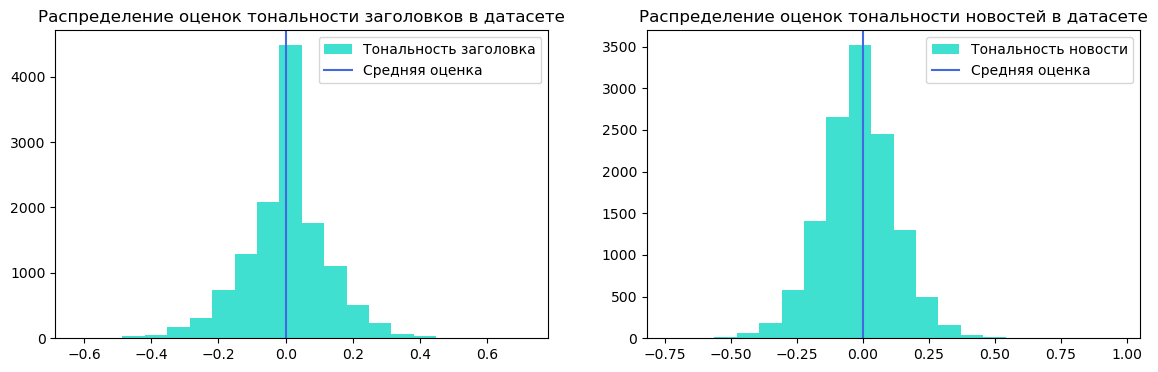

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['SentimentTitle'], bins=20, color='turquoise', label='Тональность заголовка')
axes[0].axvline(mean_val_title, color='royalblue', label='Средняя оценка')
axes[0].set_title('Распределение оценок тональности заголовков в датасете')
axes[0].legend()

axes[1].hist(data['SentimentHeadline'], bins=20, color='turquoise', label='Тональность новости')
axes[1].axvline(mean_val_title, color='royalblue', label='Средняя оценка')
axes[1].set_title('Распределение оценок тональности новостей в датасете')
axes[1].legend()

plt.grid(False)
plt.show()

Среднее значение оценки тональностей немного смещено в сторону отрицательных значений на обоих графиках. Для назначения лейбла тональности заголовка и новости разделим датасет по правилу одной сигмы.

In [7]:
lower_bound_title = mean_val_title - std_val_title
upper_bound_title = mean_val_title + std_val_title

lower_bound_head = mean_val_head - std_val_head
upper_bound_head = mean_val_head + std_val_head

def assign_sentiment(score, lower_bound, upper_bound):
    if score < lower_bound:
        return -1
    elif score > upper_bound:
        return +1
    else:
        return 0
    
data["TitleLabel"] = data["SentimentTitle"].apply(assign_sentiment, args=(lower_bound_title, upper_bound_title))
data["HeadlineLabel"] = data["SentimentHeadline"].apply(assign_sentiment, args=(lower_bound_head, upper_bound_head))

Далее отфильтруем только те строки, где лейбл тональности заголовка и текста новости совпадает.

In [8]:
data = data[data["TitleLabel"] == data["HeadlineLabel"]]
data = data.drop(["SentimentTitle", "SentimentHeadline", "HeadlineLabel"], axis=1)
data = data.rename(columns={"TitleLabel": "Target"})
data = data.reset_index(drop=True)

Визуально оценим корректность разбиения.

*Негатив*

In [9]:
data_neg = data[data['Target'] == -1]
data_neg = data_neg.reset_index(drop=True)
data_neg.loc[102, 'Headline']

"A configuration error in Microsoft's Azure Active Directory service is preventing customers from accessing a wide range of Microsoft services hosted in Europe, including Office 365 and Visual Studio Team Services. "

In [10]:
data_neg.loc[387, 'Headline']

"Microsoft has dropped bitcoin payments, just over a year after announcing it would support the virtual currency at its Windows Store. A post with the heading &quot;Microsoft Store doesn't accept bitcoin&quot; says: &quot;You can no longer redeem bitcoin into your Microsoft account. "

*Позитив*

In [11]:
data_pos = data[data['Target'] == 1]
data_pos = data_pos.reset_index(drop=True)
data_pos.loc[278, 'Headline']

'On Thursday, Microsoft reported solid quarterly earnings, and investors are pleased. The stock is up about 3% after-hours. Unlike Netflix and its'

In [12]:
data_pos.loc[407, 'Headline']

'When we think of the software industry, the first name that comes to our mind is Microsoft Corporation MSFT . Its operating systems are installed'

*Нейтрал*

In [13]:
data_neu = data[data['Target'] == 0]
data_neu = data_neu.reset_index(drop=True)
data_neu.loc[1695, 'Headline']

'SAN JOSE, Calif.--(BUSINESSWIRE)-- Kaazing, chief contributor to the WebSocket standard, today announced the launch of Kaazing WebSocket Intercloud Connect (KWIC) on the Microsoft Azure Marketplace. With '

In [14]:
data_neu.loc[5479, 'Headline']

"Microsoft is letting developers pre-order the HoloLens development edition today, but it's also detailing exactly what's inside the headset."

Можно сделать вывод, что большая часть новостей классифицирована корректно. В то же время для PR-департамента компании восприятие той или иной публикации может несколько отличаться.

Финальный датасет состоит из 7671 наблюдения.

In [15]:
data.shape

(7671, 5)

Распределение таргета таково, что в датасете преобладают нейтральные новости - около 89% всего датасета. Негатив и позитив составляют примерно равные доли - по 5-6%.

In [16]:
data['Target'].value_counts()

Target
 0    6810
-1     437
 1     424
Name: count, dtype: int64

В датасете содержатся статьи за период с 1 марта 2015 года по 29 марта 2016 года.

In [17]:
data["PublishDate"] = pd.to_datetime(data["PublishDate"])

min_date = data['PublishDate'].min()
max_date = data['PublishDate'].max()

min_date, max_date

(Timestamp('2015-03-01 00:19:00'), Timestamp('2016-03-29 01:38:00'))

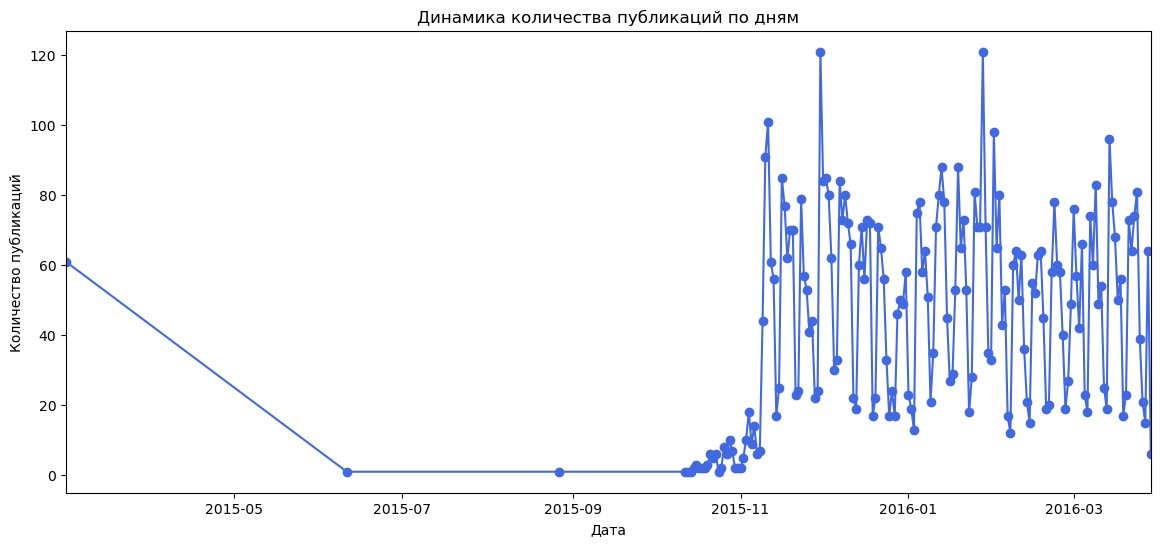

In [18]:
df = data.copy()
df["Day"] = df["PublishDate"].dt.date
daily_counts = df.groupby("Day").size()

plt.figure(figsize=(14, 6))
daily_counts.plot(kind="line", color="royalblue", marker="o")

plt.xlim(min_date, max_date)
plt.xlabel("Дата")
plt.ylabel("Количество публикаций")
plt.title("Динамика количества публикаций по дням")

plt.show()

На графике динамики количества публикаций заметим, что с июня 2015 по октябрь 2015 статьи отсутствуют. Проверив оригинальный датасет, мы можем прийти к выводу об ошибке сбора данных, оказавших влияние на финальное распределение статей во времени. Для нашей задачи этот факт не играет большой роли, однако полагаем, что тестирование reasoning-модели будет корректнее проводить на публикациях после ноября 2015.

In [19]:
data.head()

,Title,Headline,Source,PublishDate,Target
0,Intellitec Solutions to Host 13th Annual Sprin...,Over 100 attendees expected to see latest vers...,PRWeb,2015-03-01 00:19:00,0
1,Microsoft's new Windows 10 ad targets Apple,"New Delhi, Feb.29 : Technology giant Microsoft...",New Kerala,2015-03-01 01:32:00,0
2,Microsoft Project Centennial seen with “univer...,"Microsoft may have burned off one bridge, but ...",SlashGear,2015-03-01 02:14:00,0
3,Microsoft sneaks onto Android while Android sn...,The platform battles are back MWC16 +Analysis ...,The Register,2015-03-01 02:15:00,0
4,"HoloLens dev edition costs £2,000 with new Con...",Microsoft’s AR headset is being made available...,Metro,2015-03-01 02:18:00,0


# 2. Классификация

Для анализа здоровья бренда все поступающие публикации должны быть отсортированы по тональности. Так как таргет принимает значения `{-1, 0, 1}`, то мы будем работать с мультиклассовой классификацией. 

В рамках работы протестировано несколько подходов к обработке текстовых данных и получению эмбеддингов:
- CountVectorizer;
- TF-IDF;
- Word2Vec;
- предобученная модель Word2Vec;
- предобученная модель GloVe;
- Sentence Transformer.

Поверх полученных эмбеддингов применена базовая модель логистической регресии - `sklearn.linear_model.LogisticRegression`. Метрики, на основании которых делается вывод о качестве классификации, - макро `precision, recall, F1`.

 ## 2.1. Предобработка данных

Для преобработки данных проделаем следующие шаги:

- объединим колонки заголовка и текста в один признак `Text`;

- токенизируем текст с помощью функции `word_tokenize` из библиотеки `nltk`;

- очистим текст от символов, оставляя латиницу и числа, с помощью регулярных выражений;

- исключим стоп-слова для английского языка;

- лемматизируем слова через `MorphAnalyzer` в библиотеке `pymorphy3`.

In [20]:
data_preprocessed = data.copy()
data_preprocessed['Text'] = data.iloc[:, 0] + '. ' + data.iloc[:, 1] 

In [21]:
stopwords = stopwords.words('english')
en_words = re.compile("[a-zA-Z0-9]+")
lemmatizer = MorphAnalyzer()

def clean_text(texts):
    
    clean_dataset = []
    cache = {}  

    for text in texts: 
        lemmas = []
        
        for tok in word_tokenize(text.lower()):
            if not en_words.match(tok):
                continue
            if tok in stopwords:
                continue
            if tok not in cache:
                cache[tok] = lemmatizer.parse(tok)[0].normal_form
            lemmas.append(cache[tok])
            
        clean_dataset.append(lemmas)
        
    return [' '.join(w) for w in clean_dataset]

In [22]:
data_preprocessed = pd.DataFrame({"CleanText": clean_text(data_preprocessed['Text'].values), "Text": data_preprocessed['Text'].values, "Target": data_preprocessed['Target'].values})
data_preprocessed.head()

,CleanText,Text,Target
0,intellitec solutions host 13th annual spring m...,Intellitec Solutions to Host 13th Annual Sprin...,0
1,microsoft new windows 10 ad targets apple new ...,Microsoft's new Windows 10 ad targets Apple. N...,0
2,microsoft project centennial seen universal de...,Microsoft Project Centennial seen with “univer...,0
3,microsoft sneaks onto android android sneaks o...,Microsoft sneaks onto Android while Android sn...,0
4,hololens dev edition costs new conker game mic...,"HoloLens dev edition costs £2,000 with new Con...",0


Разобьем выборку на обучающую и тестовую в соотношении 80/20 с сохранением распределения таргета.

In [23]:
train, test = train_test_split(data_preprocessed, train_size=0.8, shuffle=True, stratify=data_preprocessed['Target'], random_state=42)

X_train, X_test = train['CleanText'], test['CleanText']
y_train, y_test = train['Target'], test['Target']

In [24]:
y_train.value_counts()

Target
 0    5447
-1     350
 1     339
Name: count, dtype: int64

In [25]:
y_test.value_counts()

Target
 0    1363
-1      87
 1      85
Name: count, dtype: int64

Также зададим функцию для сохранения макро-метрик в единый датафрейм.

In [26]:
def get_metrics(vectorizer_name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    
    return {"vectorizer": vectorizer_name,
            "macro_precision": report["macro avg"]["precision"],
            "macro_recall": report["macro avg"]["recall"],
            "macro_f1": report["macro avg"]["f1-score"]}

## 2.2. Векторизация и эмбеддинги
### 2.2.1. CountVectorizer

В качестве базового способа представления текста был использован подход bag of words, реализованный с помощью `CountVectorizer`.

In [27]:
count_vec = CountVectorizer()

X_train_count_vec = count_vec.fit_transform(X_train)
X_test_count_vec = count_vec.transform(X_test)

In [28]:
lr_count_vec = LogisticRegression(class_weight="balanced", random_state=42)
lr_count_vec.fit(X_train_count_vec, y_train)
pred_count_vec = lr_count_vec.predict(X_test_count_vec)
print(classification_report(y_test, pred_count_vec))

              precision    recall  f1-score   support

          -1       0.54      0.47      0.50        87
           0       0.93      0.95      0.94      1363
           1       0.52      0.44      0.47        85

    accuracy                           0.90      1535
   macro avg       0.66      0.62      0.64      1535
weighted avg       0.89      0.90      0.89      1535



In [29]:
metrics = []
metrics.append(get_metrics('CountVectorizer', y_test, pred_count_vec))

### 2.2.2. TF-IDF

Вторым классическим способом векторизации текста был выбран метод `TF-IDF`. В отличие от CountVectorizer, который учитывает только абсолютные частоты слов в документе, TF-IDF дополнительно принимает во внимание распространеность слова во всем корпусе.

In [30]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [31]:
lr_tfidf = LogisticRegression(class_weight="balanced", random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = lr_tfidf.predict(X_test_tfidf)
print(classification_report(y_test, pred_tfidf))

              precision    recall  f1-score   support

          -1       0.44      0.47      0.46        87
           0       0.94      0.91      0.93      1363
           1       0.38      0.56      0.46        85

    accuracy                           0.87      1535
   macro avg       0.59      0.65      0.61      1535
weighted avg       0.88      0.87      0.87      1535



In [32]:
metrics.append(get_metrics('TfidfVectorizer', y_test, pred_tfidf))

### 2.2.3. Word2Vec (Skip-Gram)

Модель `Word2Vec` строит плотные векторные представления слов, отражающие их семантическую близость. В данной работе используется метод Skip-Gram, когда мы пытаемся предсказать контекст по переданному модели слову. Этот метод лучше работает с маленькими текстами и лучше представляет редкие слова.

In [33]:
X_train_w2vec = [text.split() for text in tqdm(X_train)]
X_test_w2vec = [text.split() for text in tqdm(X_test)]

100%|██████████| 1535/1535 [00:00<00:00, 905266.68it/s]


In [34]:
word_2vec = Word2Vec(X_train_w2vec, workers=1, vector_size=100, min_count=3, window=5, sg=1, epochs=15, seed=42)

In [35]:
def get_mean_word_embedding(text, model):
    model = model.wv if hasattr(model, "wv") else model
    result = []

    for word in word_tokenize(text.lower()):
        if word in model:
            result.append(model[word])

    if len(result):
        result = np.mean(result, axis=0) 
    else:
        result = np.zeros(100)
    return result

X_train_w2vec_text = [get_mean_word_embedding(text, word_2vec) for text in tqdm(X_train)]
X_test_w2vec_text = [get_mean_word_embedding(text, word_2vec) for text in tqdm(X_test)]

100%|██████████| 1535/1535 [00:00<00:00, 12855.43it/s]


In [36]:
lr_w2vec = LogisticRegression(class_weight="balanced", random_state=42)
lr_w2vec.fit(X_train_w2vec_text, y_train)
pred_w2vec = lr_w2vec.predict(X_test_w2vec_text)
print(classification_report(y_test, pred_w2vec))

              precision    recall  f1-score   support

          -1       0.14      0.54      0.22        87
           0       0.93      0.53      0.68      1363
           1       0.12      0.58      0.20        85

    accuracy                           0.53      1535
   macro avg       0.40      0.55      0.36      1535
weighted avg       0.84      0.53      0.62      1535



In [37]:
metrics.append(get_metrics('Word2Vec', y_test, pred_w2vec))

### 2.2.4. Word2Vec (Skip-Gram, pretrained)

Так как качество модели Word2Vec, обученной только на имеющемся корпусе новостных текстов, оказалось ниже качества даже классических частотных методов векторизации, дополнительно были протестированы предобученные векторные представления слов.

В качестве источника был использован репозиторий [NLPL word embeddings repository](http://vectors.nlpl.eu/repository/). Для эксперимента была выбрана модель, обученная на корпусе [English Gigaword Fifth Edition](https://catalog.ldc.upenn.edu/LDC2011T07), поскольку данный корпус состоит из англоязычных новостных текстов и по домену близок к данным, используемым в работе.

In [38]:
urllib.request.urlretrieve("https://vectors.nlpl.eu/repository/20/11.zip", "gigaword5_w2v.zip")

('gigaword5_w2v.zip', <http.client.HTTPMessage at 0x2404180ed50>)

In [39]:
if not os.path.exists("models"):
    os.mkdir('models')

with ZipFile('gigaword5_w2v.zip', 'r') as zf:
    bin_file = [name for name in zf.namelist() if name.endswith(".bin")][0]
    with zf.open(bin_file) as source, open("models/gigaword_w2v.bin", "wb") as target:
        shutil.copyfileobj(source, target)

In [40]:
word_2vec_pretr = KeyedVectors.load_word2vec_format('models/gigaword_w2v.bin', binary=True)
X_train_w2vec_pretr = [get_mean_word_embedding(text, word_2vec_pretr) for text in tqdm(X_train)]
X_test_w2vec_pretr = [get_mean_word_embedding(text, word_2vec_pretr) for text in tqdm(X_test)]

100%|██████████| 1535/1535 [00:00<00:00, 12459.45it/s]


In [41]:
lr_w2vec_pretr = LogisticRegression(class_weight="balanced", random_state=42)
lr_w2vec_pretr.fit(X_train_w2vec_pretr, y_train)
pred_w2vec_pretr = lr_w2vec_pretr.predict(X_test_w2vec_pretr)
print(classification_report(y_test, pred_w2vec_pretr))

              precision    recall  f1-score   support

          -1       0.14      0.54      0.23        87
           0       0.94      0.59      0.73      1363
           1       0.16      0.66      0.26        85

    accuracy                           0.59      1535
   macro avg       0.42      0.60      0.40      1535
weighted avg       0.86      0.59      0.67      1535



In [42]:
metrics.append(get_metrics('Word2Vec (pretrained)', y_test, pred_w2vec_pretr))

### 2.2.5. GloVe (pretrained)

Дополнительно были протестированы предобученные эмбеддинги `GloVe`. Если Word2Vec обучается на задаче предсказания контекстных слов, то GloVe строит векторные представления на основе глобальной статистики совместной встречаемости слов в корпусе.

Предобученная модель GloVe взята из репозитория [NLPL word embeddings repository](http://vectors.nlpl.eu/repository/). Модель также обучена на корпусе [English Gigaword Fifth Edition](https://catalog.ldc.upenn.edu/LDC2011T07).

In [43]:
urllib.request.urlretrieve("https://vectors.nlpl.eu/repository/20/14.zip", "gigaword5_glove.zip")

('gigaword5_glove.zip', <http.client.HTTPMessage at 0x240467a4770>)

In [44]:
with ZipFile('gigaword5_glove.zip', 'r') as zf:
    bin_file = [name for name in zf.namelist() if name.endswith(".bin")][0]
    with zf.open(bin_file) as source, open("models/gigaword_glove.bin", "wb") as target:
        shutil.copyfileobj(source, target)

In [45]:
glove_pretr = KeyedVectors.load_word2vec_format('models/gigaword_glove.bin', binary=True)
X_train_glove_pretr = [get_mean_word_embedding(text, glove_pretr) for text in tqdm(X_train)]
X_test_glove_pretr = [get_mean_word_embedding(text, glove_pretr) for text in tqdm(X_test)]

100%|██████████| 1535/1535 [00:00<00:00, 11026.30it/s]


In [46]:
lr_glove_pretr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_glove_pretr.fit(X_train_glove_pretr, y_train)
pred_glove_pretr = lr_glove_pretr.predict(X_test_glove_pretr)
print(classification_report(y_test, pred_glove_pretr))

              precision    recall  f1-score   support

          -1       0.16      0.47      0.24        87
           0       0.94      0.66      0.77      1363
           1       0.16      0.64      0.26        85

    accuracy                           0.64      1535
   macro avg       0.42      0.59      0.42      1535
weighted avg       0.85      0.64      0.71      1535



In [47]:
metrics.append(get_metrics('GloVe (pretrained)', y_test, pred_glove_pretr))

### 2.2.6. Sentence Transformers

В качестве современного подхода к построению контекстных представлений текста была использована модель, обученная на задаче `sentence-transformers`: `sentence-transformers/all-mpnet-base-v2`.

Так как трансформер обучался на корпусе естественных текстов, мы будем тестировать модель на оригинальном тексте новости, а не очищенном.

In [48]:
X_train_ori, X_test_ori = train['Text'], test['Text']

sent_transformer = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
X_train_stran = sent_transformer.encode(X_train_ori.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
X_test_stran = sent_transformer.encode(X_test_ori.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/192 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

In [49]:
lr_stran = LogisticRegression(class_weight="balanced", random_state=42)
lr_stran.fit(X_train_stran, y_train)
pred_stran = lr_stran.predict(X_test_stran)
print(classification_report(y_test, pred_stran))

              precision    recall  f1-score   support

          -1       0.17      0.57      0.27        87
           0       0.94      0.64      0.76      1363
           1       0.15      0.55      0.24        85

    accuracy                           0.64      1535
   macro avg       0.42      0.59      0.42      1535
weighted avg       0.85      0.64      0.71      1535



In [50]:
metrics.append(get_metrics('Sentence Transformer', y_test, pred_stran))

### 2.2.7. Обсуждение полученных результатов

Для каждого из рассмотренных способов векторизации и подготовки эмбеддингов использовалась логистическая регрессия с единым набором параметров. Такой подход позволяет сравнить именно способы представления текста, минимизируя влияние выбора классификатора. Оценка качества проводилась по макро-метрикам precision, recall и F1, т.к. классы в задаче несбалансированы.

Полученные результаты показывают, что наилучшее значение макро F1 было достигнуто при использовании CountVectorizer. Несмотря на простоту данного подхода, он оказался наиболее эффективным на рассматриваемом наборе данных.

In [51]:
pd.DataFrame(metrics).sort_values(by='macro_f1', ascending=False, ignore_index=True)

,vectorizer,macro_precision,macro_recall,macro_f1
0,CountVectorizer,0.664773,0.619134,0.639876
1,TfidfVectorizer,0.589051,0.648821,0.612939
2,GloVe (pretrained),0.421804,0.587488,0.424719
3,Sentence Transformer,0.421313,0.590607,0.422481
4,Word2Vec (pretrained),0.415629,0.597043,0.403396
5,Word2Vec,0.395235,0.548805,0.362925


In [55]:
feature_names = np.array(count_vec.get_feature_names_out())

for class_label, coef in zip(lr_count_vec.classes_, lr_count_vec.coef_):
    top_idx = np.argsort(coef)[-20:]
    print(f"\nClass {class_label}")
    print(feature_names[top_idx])


Class -1
['taken' 'risk' 'final' 'fable' 'hat' 'google' 'recognition' 'problem'
 'unwanted' 'growth' 'red' 'free' 'head' 'device' 'keep' 'small'
 'commercial' 'line' 'chat' 'support']

Class 0
['december' '000' 'later' 'video' 'likely' 'test' 'dynamics' 'protection'
 'buyers' 'brings' 'sql' 'to' 'nasdaq' 'government' 'purchased' 'want'
 'july' 'four' 'decision' 'sleep']

Class 1
['emotion' 'reportedly' 'box' 'alarm' 'select' 'successful' 'details'
 'best' 'fitness' 'better' 'aggressive' 'season' 'china' 'enable'
 'certified' 'premium' 'first' 'improved' 'health' 'available']
